In [33]:
# Uncomment line below to install exlib
# !pip install diskcache
import sys; 
sys.path.append('../src')

ROOT_DIR = '..'

import openai
import os

# with open(f"{ROOT_DIR}/API_KEY.txt", "r") as file:
#     api_key = file.read().strip()
# with open(f"{ROOT_DIR}/API_KEY.txt", "r") as file:
#     api_key = file.read().strip()
import json
with open(f"{ROOT_DIR}/API_KEYS2.json", "r") as file:
    api_keys = json.load(file)

os.environ['OPENAI_API_KEY'] = api_keys['OPENAI_API_KEY']
os.environ['ANTHROPIC_API_KEY'] = api_keys['ANTHROPIC_API_KEY']
os.environ['GOOGLE_API_KEY'] = api_keys['GOOGLE_API_KEY']
os.environ['CACHE_DIR'] = os.path.join(ROOT_DIR, 'cache_dir3')

In [34]:
import importlib
import sys; sys.path.append("../src")
import cholec
importlib.reload(cholec)
from cholec import get_llm_generated_answer
from cholec import CholecExample, CholecDataset, load_model, items_to_examples
from cholec import isolate_individual_features, distill_relevant_features, calculate_expert_alignment_scores

In [35]:
dataset = CholecDataset(split="test")
num_samples = 3
items = [dataset[i] for i in range(num_samples)]

In [36]:
anno_filenames = [
    "cholec80_video57_008.png",
    "cholec80_video04_005.png",
    "M2CCAI2016_video97_005.png",
    "cholec80_video55_008.png",
    "M2CCAI2016_video116_008.png",
]

In [5]:
idxs = [i for i in range(len(dataset)) if dataset[i]['id'] in anno_filenames]
idxs

[22, 35, 70, 173, 189]

In [6]:
for idx in idxs:
    print(idx, dataset[idx]['id'])

22 M2CCAI2016_video116_008.png
35 M2CCAI2016_video97_005.png
70 cholec80_video04_005.png
173 cholec80_video55_008.png
189 cholec80_video57_008.png


In [7]:
sorted_idxs = sorted(idxs, key=lambda idx: anno_filenames.index(dataset[idx]['id']))
sorted_idxs

[189, 70, 35, 173, 22]

In [8]:
from tqdm.auto import tqdm
import json

In [9]:
# model = 'gpt-4o'
models = [
    'gpt-4o',
    'claude-3-5-sonnet-latest',
    'gemini-2.0-flash',
    'o1'
]

eval_model = 'gpt-4o'

methods = ['vanilla', 'cot', 'socratic', 'subq']

In [10]:
import json
import copy
import os
from tqdm.auto import tqdm

method = methods[0]
model = models[0]

load_path = os.path.join(ROOT_DIR, f'results/{method}/cholec_{model}.json')
save_path = os.path.join(ROOT_DIR, f'results/{method}/cholec_{model}_annotation.json')

with open(load_path) as input_file:
    results = json.load(input_file)


In [11]:
# results[0]
results_idxs = [i for i in range(len(results)) if results[i]['id'] in anno_filenames]
results_idxs

[3, 4, 7, 10, 13]

In [28]:
import json
import copy
import os
from tqdm.auto import tqdm

method = methods[0]
model = models[0]

load_path = os.path.join(ROOT_DIR, f'results/{method}/cholec_{model}.json')
save_path = os.path.join(ROOT_DIR, f'results/{method}/cholec_{model}_annotation.json')

with open(load_path) as input_file:
    results = json.load(input_file)

new_results = {}

# num_examples = len(results)
# sampled_idxs = [92, 2, 35, 53, 77]

sampled_idxs = results_idxs

for di in tqdm(sampled_idxs):
    result = results[di]
    relevant_claims = result['relevant_claims']

    # calculate expert alignment scores
    align_infos = calculate_expert_alignment_scores(
        relevant_claims, 
        eval_model,
    )

    alignable_claims = [info["Claim"] for info in align_infos]
    alignment_categories = [info["Category"] for info in align_infos]
    aligned_category_ids = [info["Category ID"] for info in align_infos]
    alignment_scores = [info["Alignment"] for info in align_infos]
    alignment_raws = [info["Alignment Raw"] for info in align_infos]
    alignment_reasonings = [info["Reasoning"] for info in align_infos]

    new_result = copy.deepcopy(result)

    new_result['alignable_claims'] = alignable_claims
    new_result['alignment_categories'] = alignment_categories
    new_result['aligned_category_ids'] = aligned_category_ids
    new_result['alignment_scores'] = alignment_scores
    new_result['alignment_raws'] = alignment_raws
    new_result['alignment_reasonings'] = alignment_reasonings
    
    # Non-alignable claims are given a score of 0.0
    if len(align_infos) > 0:
        new_result['final_alignment_score'] = sum(info["Alignment"] for info in align_infos) / len(new_result['all_claims'])
    else:
        new_result['final_alignment_score'] = 0.0

    new_results[di] = new_result


with open(save_path, 'wt') as output_file:
    json.dump(new_results, output_file, indent=4)

  0%|          | 0/5 [00:00<?, ?it/s]

In [29]:
new_results;

In [86]:
import json
import os

ROOT_DIR = '..'

load_path = os.path.join(ROOT_DIR, 'results/vanilla/cholec_gpt-4o_annotation_v1.json')

with open(load_path) as input_file:
    results = json.load(input_file)
    
sampled_idxs = [3, 4, 7, 10, 13]

new_results = {}
for idx in sampled_idxs:
# for idx in range(len(sampled_idxs)):
    result = results[str(idx)]
    new_result = {}
    for key, val in result.items():
        if key != 'input':
            new_result[key] = val
    new_results[idx] = new_result
    
os.makedirs('annotations', exist_ok=True)
with open('annotations/cholec_amateur.json', 'wt') as output_file:
    json.dump(new_results, output_file, indent=4)

In [42]:
results['3']['llm_safe_list'], results['3']['llm_unsafe_list']

([5, 6, 7, 20, 21, 22, 23, 36, 37, 38, 52, 53, 54],
 [61,
  62,
  63,
  64,
  76,
  77,
  78,
  79,
  80,
  88,
  89,
  90,
  91,
  92,
  104,
  105,
  106,
  107,
  108,
  120,
  121,
  122,
  123,
  124,
  125,
  136,
  137,
  138,
  139,
  140,
  141])

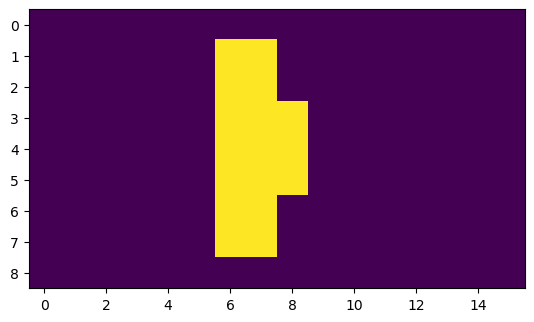

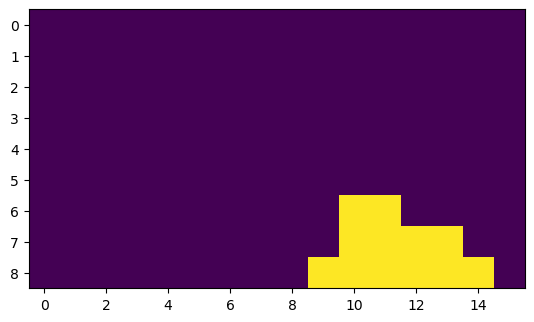

In [47]:
import torch

llm_safe_mask = torch.zeros(9 * 16)
llm_safe_mask[results['3']['true_safe_list']] = 1
llm_safe_mask = llm_safe_mask.reshape(9, 16)

llm_unsafe_mask = torch.zeros(9 * 16)
llm_unsafe_mask[results['3']['true_unsafe_list']] = 1
llm_unsafe_mask = llm_unsafe_mask.reshape(9, 16)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(llm_safe_mask)
plt.show()

plt.figure()
plt.imshow(llm_unsafe_mask)
plt.show()

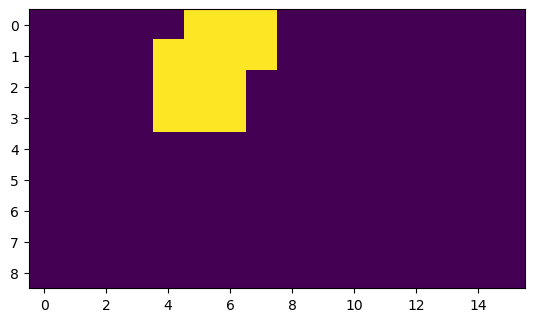

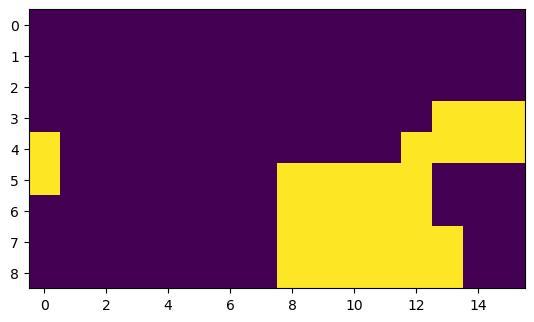

In [46]:
import torch

llm_safe_mask = torch.zeros(9 * 16)
llm_safe_mask[results['3']['llm_safe_list']] = 1
llm_safe_mask = llm_safe_mask.reshape(9, 16)

llm_unsafe_mask = torch.zeros(9 * 16)
llm_unsafe_mask[results['3']['llm_unsafe_list']] = 1
llm_unsafe_mask = llm_unsafe_mask.reshape(9, 16)

import matplotlib.pyplot as plt

plt.figure()
plt.imshow(llm_safe_mask)
plt.show()

plt.figure()
plt.imshow(llm_unsafe_mask)
plt.show()

In [74]:
from matplotlib.colors import LinearSegmentedColormap
def get_masked_image(image, masks, colors=['black', 'green', 'red'], mask_mode='default', verbose=False):
    """
    image (C, H, W)
    mask (H, W)
    Assume mask[0] is everything else mask
    """
    
    # assert mask_mode in ['default', 'jet', 'color', 'hatch']
    # if mask_mode in ['color', 'hatch']:
    #     assert len(colors) == len(masks.unique()) - sometimes some mask might not exist
    
    image_test = image
    
    # Desired pixel dimensions
    width_in_pixels = image.shape[-2]
    height_in_pixels = image.shape[-1]
    dpi = 100  # Dots per inch

    # Calculate figsize in inches
    figsize = (width_in_pixels / dpi, height_in_pixels / dpi)
    # Create the figure with the desired dimensions
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    
    if mask_mode == 'default':
        ax.imshow(image_test.permute(1,2,0).cpu())
        ax.imshow(masks.cpu(), alpha=0.5)
    elif mask_mode == 'color':
        # make each mask a different color
        # todo
        ax.imshow(image_test.permute(1,2,0).cpu())
        cmap = LinearSegmentedColormap.from_list("my_colormap", colors, N=100)
        ax.imshow(masks.cpu(), alpha=0.5, cmap=cmap, vmin=0, vmax=len(colors)-1)
    elif mask_mode == 'hatch': # hatch
        ax.imshow(image_test.permute(1,2,0).cpu())
        for mi in range(len(colors)):
            if (masks == mi).cpu().float().sum() == 0:
                continue
            plot_hatch(image_test.permute(1,2,0).cpu(), 
                       (masks == mi).cpu().float(), ax, c=0.5, color=colors[mi], hatch=(colors[mi] is None))
    else:
        ax.imshow(image_test.permute(1,2,0).cpu())
        ax.imshow(masks.cpu(), alpha=0.5, cmap=mask_mode)
        
    # plt.imshow(safe_mask.cpu().numpy(), alpha=0.5)
    # show organs safe
    ax.axis('off')
    
    buf = io.BytesIO()
    plt.savefig(buf, format='png', bbox_inches='tight', pad_inches=0)  # Remove padding
    if verbose:
        plt.show()
    plt.close(fig)
    buf.seek(0)
    
    # Load the image buffer into a PIL image
    new_image = Image.open(buf)

    # Resize explicitly to ensure exact dimensions (just in case)
    new_image = new_image.resize((height_in_pixels, width_in_pixels), Image.Resampling.LANCZOS)

    # Convert the PIL image to a PyTorch tensor
    image_tensor = torch.from_numpy(np.array(new_image)).permute(2, 0, 1)  # Convert to (C, H, W)
    return image_tensor[:3]

3 /shared_data0/weiqiuy/real_drs/data/abdomen_exlib/images/cholec80_video57_008.png


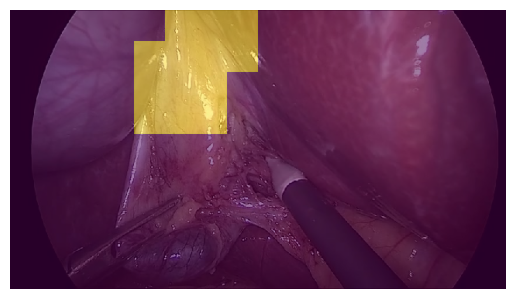

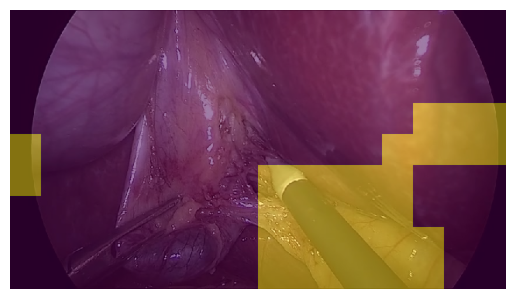

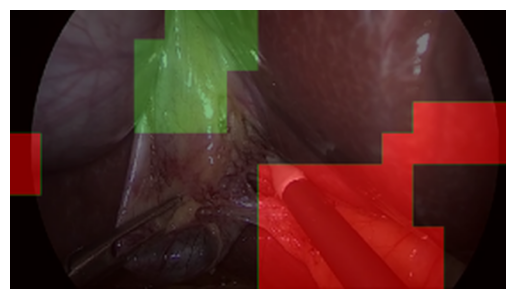

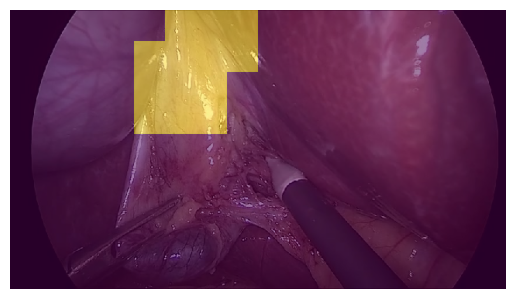

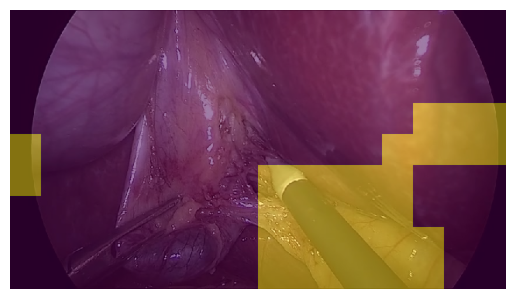

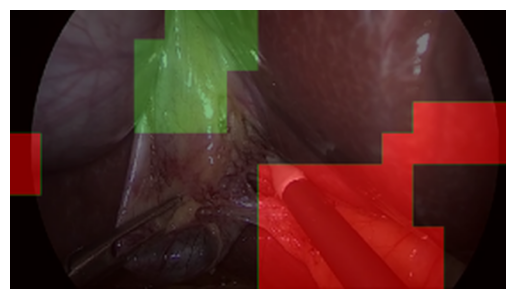

4 /shared_data0/weiqiuy/real_drs/data/abdomen_exlib/images/cholec80_video04_005.png


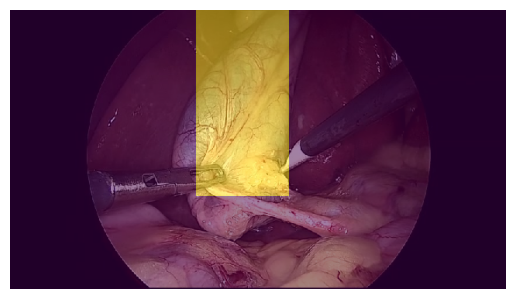

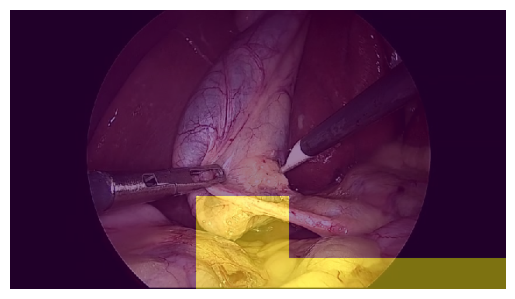

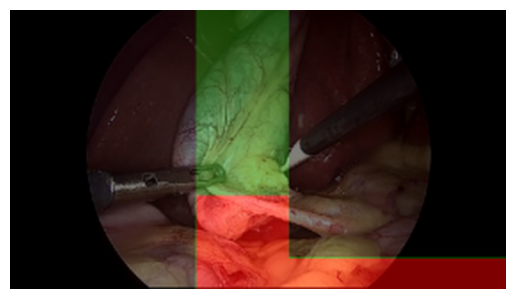

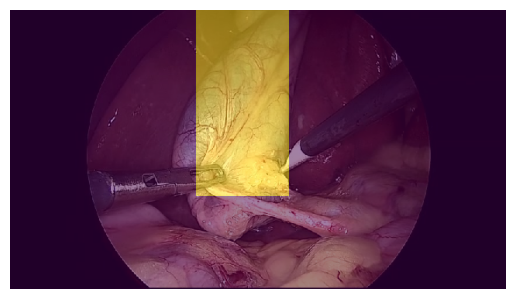

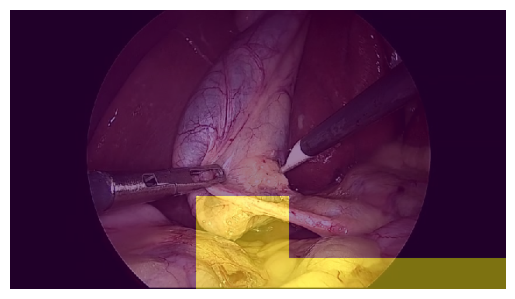

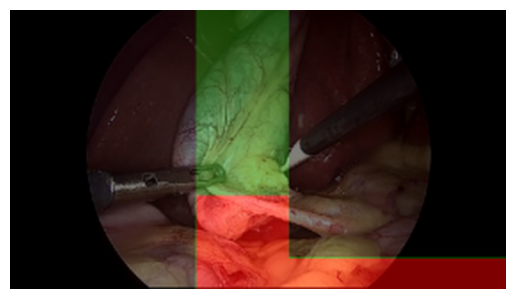

7 /shared_data0/weiqiuy/real_drs/data/abdomen_exlib/images/M2CCAI2016_video97_005.png


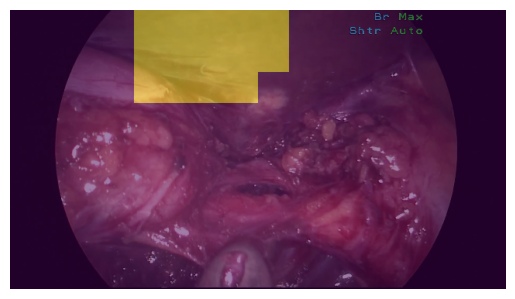

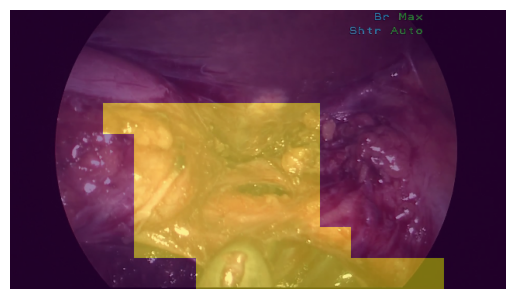

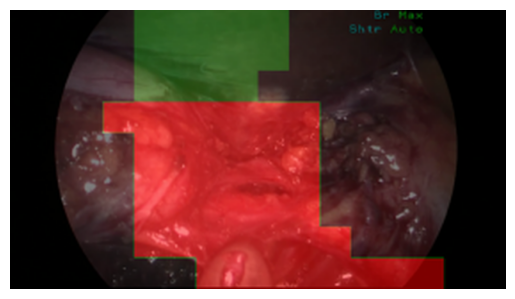

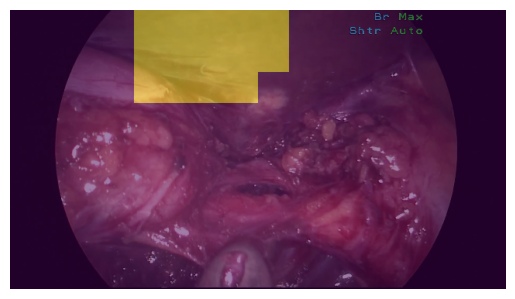

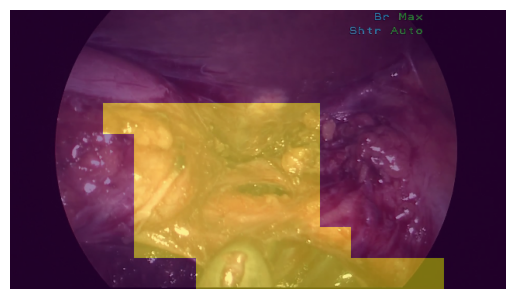

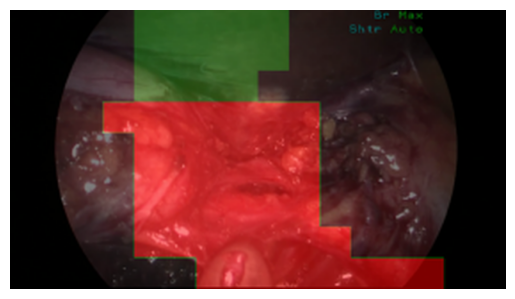

10 /shared_data0/weiqiuy/real_drs/data/abdomen_exlib/images/cholec80_video55_008.png


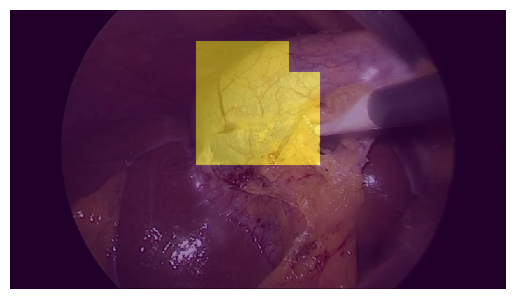

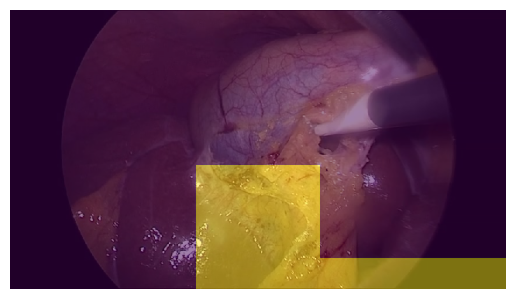

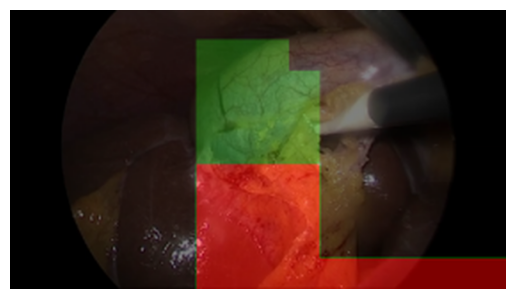

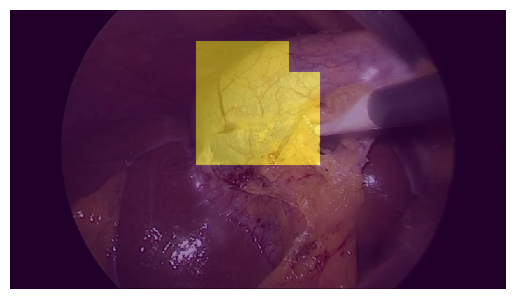

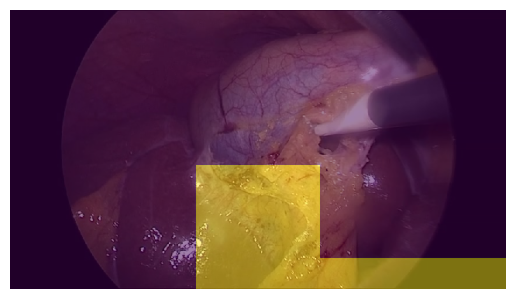

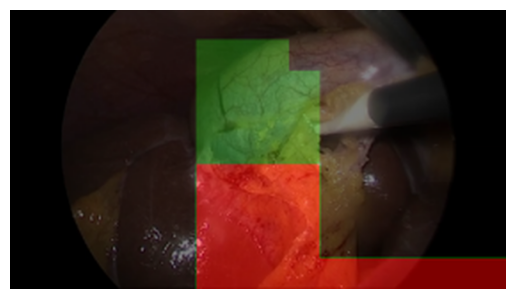

13 /shared_data0/weiqiuy/real_drs/data/abdomen_exlib/images/M2CCAI2016_video116_008.png


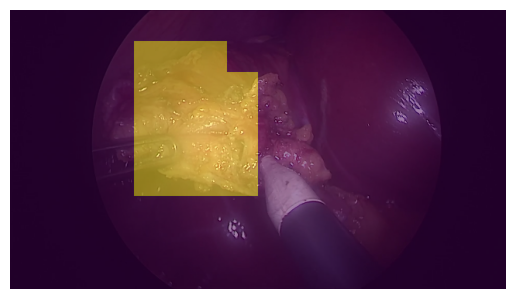

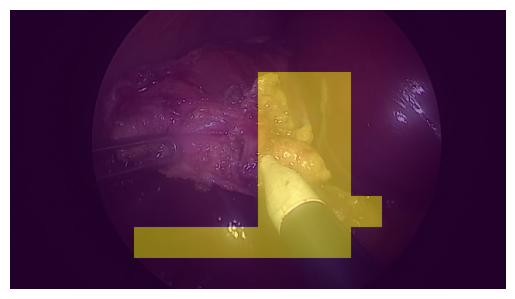

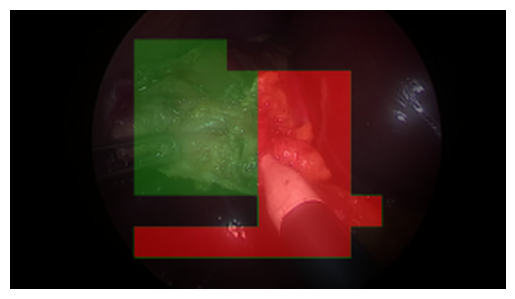

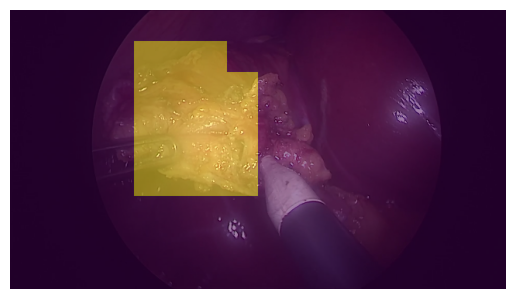

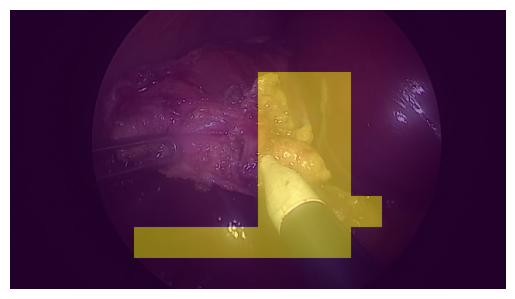

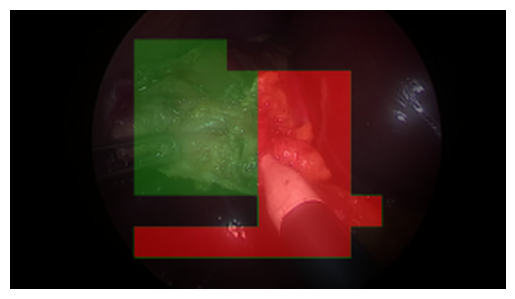

In [90]:
import torch
import numpy as np
from PIL import Image
import torch.nn.functional as F
import io

import torch
import matplotlib.pyplot as plt

for di in sampled_idxs:
    llm_safe_mask = torch.zeros(9 * 16)
    llm_safe_mask[results[str(di)]['llm_safe_list']] = 1
    llm_safe_mask = llm_safe_mask.reshape(9, 16)

    llm_unsafe_mask = torch.zeros(9 * 16)
    llm_unsafe_mask[results[str(di)]['llm_unsafe_list']] = 1
    llm_unsafe_mask = llm_unsafe_mask.reshape(9, 16)


    image_dir = '/shared_data0/weiqiuy/real_drs/data/abdomen_exlib/images'
    image_path = os.path.join(image_dir, results[str(di)]['id'])
    img = Image.open(image_path)
    print(di, image_path)

    img_array = np.array(img)                       # shape: (H, W, C)
    img_tensor = torch.from_numpy(img_array)        # shape: (H, W, C)
    img_tensor = img_tensor.permute(2, 0, 1)        # convert to (C, H, W)
    img_tensor = img_tensor.float() / 255.0         # scale to [0,1]


    # mask: PIL.Image (e.g. mode "L" or "P")
    # image: PIL.Image
    llm_safe_mask_resized = F.interpolate(llm_safe_mask.unsqueeze(0).unsqueeze(0),
                                 size=img_tensor.shape[1:],
                                 mode='nearest').squeeze(0).squeeze(0)
    llm_unsafe_mask_resized = F.interpolate(llm_unsafe_mask.unsqueeze(0).unsqueeze(0),
                                 size=img_tensor.shape[1:],
                                 mode='nearest').squeeze(0).squeeze(0)

    annotation_image_dir = 'annotation_images'
    os.makedirs(annotation_image_dir, exist_ok=True)

    plt.figure()
    plt.imshow(img_tensor.permute(1,2,0))
    plt.imshow(llm_safe_mask_resized, alpha=0.5)
    plt.axis('off')
    plt.savefig(os.path.join(annotation_image_dir, f'cholec_{di}_llm_safe.pdf'), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

    plt.figure()
    plt.imshow(img_tensor.permute(1,2,0))
    plt.imshow(llm_unsafe_mask_resized, alpha=0.5)
    plt.axis('off')
    plt.savefig(os.path.join(annotation_image_dir, f'cholec_{di}_llm_unsafe.pdf'), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

    masked_image = get_masked_image(img_tensor, llm_safe_mask_resized * 1 + llm_unsafe_mask_resized * 2,
                                   mask_mode='color')

    plt.figure()
    plt.imshow(masked_image.permute(1,2,0))
    plt.axis('off')
    plt.savefig(os.path.join(annotation_image_dir, f'cholec_{di}_llm_combined.pdf'), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()
    
    plt.figure()
    plt.imshow(img_tensor.permute(1,2,0))
    plt.imshow(llm_safe_mask_resized, alpha=0.5)
    plt.axis('off')
    plt.savefig(os.path.join(annotation_image_dir, f'cholec_{di}_llm_safe.png'), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

    plt.figure()
    plt.imshow(img_tensor.permute(1,2,0))
    plt.imshow(llm_unsafe_mask_resized, alpha=0.5)
    plt.axis('off')
    plt.savefig(os.path.join(annotation_image_dir, f'cholec_{di}_llm_unsafe.png'), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

    masked_image = get_masked_image(img_tensor, llm_safe_mask_resized * 1 + llm_unsafe_mask_resized * 2,
                                   mask_mode='color')

    plt.figure()
    plt.imshow(masked_image.permute(1,2,0))
    plt.axis('off')
    plt.savefig(os.path.join(annotation_image_dir, f'cholec_{di}_llm_combined.png'), dpi=300, bbox_inches='tight', pad_inches=0)
    plt.show()

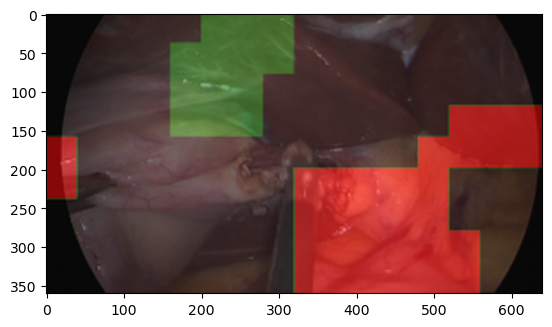

In [77]:
combined_mask = llm_safe_mask * 1 + llm_unsafe_mask * 2

mask_resized = F.interpolate(combined_mask.unsqueeze(0).unsqueeze(0),
                             size=img_tensor.shape[1:],
                             mode='nearest').squeeze(0).squeeze(0)

masked_image = get_masked_image(img_tensor, mask_resized,
                               mask_mode='color')
plt.imshow(masked_image.permute(1,2,0))

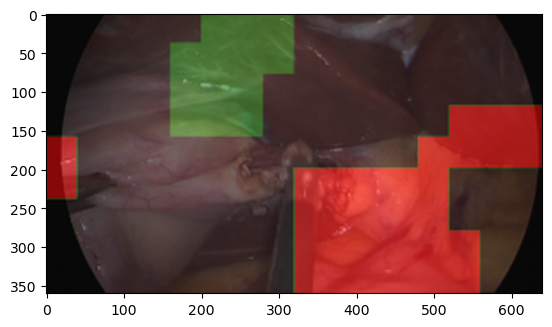

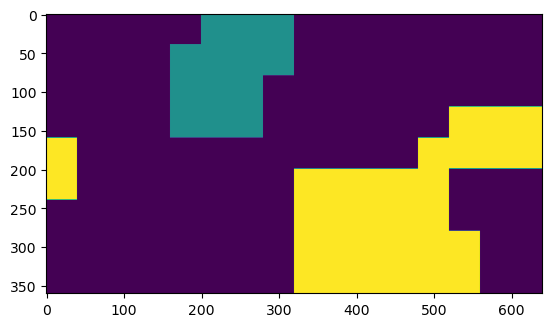

In [76]:
plt.imshow(llm_safe_mask_resized * 1 + llm_unsafe_mask_resized * 2)

In [43]:
dataset[3]

{'id': 'M2CCAI2016_video107_004.png',
 'image': tensor([[[0.0645, 0.0645, 0.0645,  ..., 0.0645, 0.0645, 0.0645],
          [0.0649, 0.0649, 0.0649,  ..., 0.0649, 0.0649, 0.0649],
          [0.0627, 0.0627, 0.0627,  ..., 0.0627, 0.0627, 0.0627],
          ...,
          [0.0627, 0.0627, 0.0627,  ..., 0.0627, 0.0627, 0.0627],
          [0.0641, 0.0641, 0.0641,  ..., 0.0641, 0.0641, 0.0641],
          [0.0665, 0.0665, 0.0665,  ..., 0.0665, 0.0665, 0.0665]],
 
         [[0.0645, 0.0645, 0.0645,  ..., 0.0645, 0.0645, 0.0645],
          [0.0649, 0.0649, 0.0649,  ..., 0.0649, 0.0649, 0.0649],
          [0.0630, 0.0630, 0.0630,  ..., 0.0630, 0.0630, 0.0630],
          ...,
          [0.0627, 0.0627, 0.0627,  ..., 0.0627, 0.0627, 0.0627],
          [0.0641, 0.0641, 0.0641,  ..., 0.0641, 0.0641, 0.0641],
          [0.0665, 0.0665, 0.0665,  ..., 0.0665, 0.0665, 0.0665]],
 
         [[0.0645, 0.0645, 0.0645,  ..., 0.0645, 0.0645, 0.0645],
          [0.0649, 0.0649, 0.0649,  ..., 0.0649, 0.0649, 0.

In [31]:
import json
from pathlib import Path
from itertools import zip_longest

IN_PATH = Path(load_path)   # update path if needed
OUT_PATH = Path("annotations/tfix_cholec_annotation_sheet.md")

# ----------------------------- #
# Canonical Cholec categories   #
# ----------------------------- #
CHOLEC_CATEGORY_MAP = {
    1: "Calot's triangle cleared - Hepatocystic triangle must be fully cleared of fat/fibrosis so that its boundaries are unmistakable.",
    2: "Cystic plate exposed - The lower third of the gallbladder must be dissected off the liver to reveal the shiny cystic plate and ensure the correct dissection plane.",
    3: "Only two structures visible - Only the cystic duct and cystic artery should be seen entering the gallbladder before any clipping or cutting.",
    4: "Above the R4U line - Dissection must remain cephalad to an imaginary line from Rouviere's sulcus to liver segment IV umbilical fissure to avoid the common bile duct. Dissection should be carried out along the inferior edge of the gallbladder (well above the line of safety).",
    5: "Infundibulum start point - Dissection can begin at the gallbladder infundibulum-cystic duct junction to stay in safe tissue planes, or at the lateral or medial edges of the gallbladder above Rouviere’s sulcus or along the cystic plate to get mobility of the gallbladder first.",
    6: "Peritoneal plane - When separating the gallbladder from the liver, stay in the avascular peritoneal cleavage plane.",
    7: "Cystic lymph node (calot's node) guide - Identify the cystic lymph node and clip the artery on the gallbladder side of the node to avoid injuring the hepatic artery.",
    8: "No division without ID - Never divide any duct or vessel until it is unequivocally identified as the cystic structure entering the gallbladder.",
    9: "Inflammation bailout - If dense scarring or distorted anatomy obscures Calot's triangle, convert to open surgery or a fenestrated subtotal approach rather than blind cutting.",
}

# Light synonym map to normalize free-text to canonical IDs (add as needed)
# Keys are lowercased substrings to match.
CHOLEC_SYNONYMS = [
    (1, ["calot", "hepatocystic triangle", "triangle cleared"]),
    (2, ["cystic plate", "shiny cystic plate"]),
    (3, ["only two structures", "two structures", "cystic duct", "cystic artery"]),
    (4, ["r4u", "rouviere", "line of safety", "umbilical fissure"]),
    (5, ["infundibulum", "start point", "lateral edge", "medial edge"]),
    (6, ["peritoneal plane", "avascular plane", "subserosal plane"]),
    (7, ["cystic lymph node", "calot's node", "lymph node"]),
    (8, ["no division", "until identified", "unequivocally identified"]),
    (9, ["inflammation bailout", "dense scarring", "subtotal", "convert to open"]),
]

def _normalize_category(cat):
    """
    Accepts int/str; returns canonical category string if recognized, else str(cat).
    """
    if cat is None:
        return ""
    # If it's an int or numeric string -> map directly if possible
    try:
        cid = int(str(cat).strip())
        return CHOLEC_CATEGORY_MAP.get(cid, str(cat))
    except Exception:
        pass

    s = str(cat).strip()
    sl = s.lower()
    # Try fuzzy match via synonyms
    for cid, keys in CHOLEC_SYNONYMS:
        if any(k in sl for k in keys):
            return CHOLEC_CATEGORY_MAP[cid]
    # If user pasted the full canonical name already, keep it
    for cid, full in CHOLEC_CATEGORY_MAP.items():
        if sl == full.lower():
            return full
    return s

def _normalize_raw(raw):
    raw_str = str(raw).strip().lower()
    if raw_str in {"complete", "partial", "none"}:
        return raw_str
    return {
        "1": "complete", "1.0": "complete",
        "0.5": "partial",
        "0.0": "none", "0": "none"
    }.get(raw_str, raw_str)

def iter_examples(data):
    """Yield (ex_id:str, block:dict) from top-level list/dict or dict with 'examples'."""
    if isinstance(data, dict):
        if isinstance(data.get("examples"), list):
            for i, b in enumerate(data["examples"], 1):
                ex_id = (b.get("id") if isinstance(b, dict) else None) or i
                yield str(ex_id), b
        else:
            keys = list(data.keys())
            try:
                keys = sorted(keys, key=lambda k: int(k))
            except Exception:
                keys = sorted(keys, key=str)
            for k in keys:
                yield str(k), data[k]
    elif isinstance(data, list):
        for i, b in enumerate(data, 1):
            ex_id = (b.get("id") if isinstance(b, dict) else None) or i
            yield str(ex_id), b
    else:
        raise ValueError("Unsupported top-level JSON: expected object or array (or dict with 'examples').")

def format_example(ex_id: str, block: dict) -> str:
    lines = []
    lines.append(f"## Example {ex_id}\n")

    # --- Explanation only (Cholec) ---
    expl = (block.get("llm_explanation") or "").strip()
    if expl:
        lines.append("--- **LLM Explanation** ---")
        lines.append(expl + "\n")

    # --- Raw inputs for views ---
    claims = list(block.get("claims", []) or [])
    relevant_claims_input = block.get("relevant_claims", []) or []
    relevant_claims_set = {str(x) for x in relevant_claims_input}

    alignable = list(block.get("alignable_claims", []) or [])
    cats_in   = list(block.get("alignment_categories", []) or [])
    raws      = list(block.get("alignment_raws", []) or [])

    # Reasonings: list (parallel) or dict keyed by claim
    reasonings_raw = block.get("alignment_reasonings", []) or []
    if isinstance(reasonings_raw, dict):
        reasonings = [reasonings_raw.get(str(c), "") for c in alignable]
    else:
        reasonings = list(reasonings_raw)

    # Normalize categories:
    cats_norm = []
    if cats_in:
        cats_norm = [_normalize_category(c) for c in cats_in]
    elif alignable and block.get("aligned_category_ids"):
        cats_norm = [_normalize_category(i) for i in block.get("aligned_category_ids", [])]

    quads = list(zip_longest(alignable, cats_norm, raws, reasonings, fillvalue=""))

    # --- Three views ---
    if claims:
        lines.append("--- **Decomposed Claims (from LLM)** ---")
        for i, c in enumerate(claims, 1):
            lines.append(f"{i}. {c}")
        lines.append("")

    lines.append("--- **Model-Marked Relevant Claims** ---")
    ordered_rel = [c for c in claims if str(c) in relevant_claims_set]
    extras_rel = [c for c in relevant_claims_input if str(c) not in {str(x) for x in ordered_rel}]
    all_rel = ordered_rel + extras_rel
    if all_rel:
        for i, c in enumerate(all_rel, 1):
            lines.append(f"{i}. {c}")
        lines.append("")
    else:
        lines.append("_None provided (annotators should still label relevance per claim below)._")
        lines.append("")

    if quads and any(alignable):
        lines.append("--- **Alignment Categories (for relevant/alignable claims)** ---")
        for claim, cat, raw, rsn in quads:
            lines.append(f"- **{claim}**  ")
            if cat or raw:
                lines.append(f"  Alignment category: *{str(cat).strip()}*, **{_normalize_raw(raw)}**")
            if rsn:
                lines.append(f"  Reasoning: {str(rsn).strip()}")
        lines.append("")

    # Build per-claim checklist (all decomposed claims + extras)
    extras = []
    if alignable:
        extras += [c for c in alignable if c not in claims]
    if quads:
        extras += [c for (c, _, _, _) in quads if c not in claims and c not in extras]
    claims_to_show = claims + extras

    # Prefill maps for provided accuracies
    rf_pairs = block.get("relevance_filtering_accuracy") or []
    ea_pairs = block.get("expert_alignment_accuracy") or []
    rf_map, ea_map = {}, {}
    for item in rf_pairs:
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            rf_map[str(item[1])] = item[0]
        elif isinstance(item, dict):
            rf_map[str(item.get("claim"))] = item.get("score")
    for item in ea_pairs:
        if isinstance(item, (list, tuple)) and len(item) >= 2:
            ea_map[str(item[1])] = item[0]
        elif isinstance(item, dict):
            ea_map[str(item.get("claim"))] = item.get("score")

    # Lookup alignment info by claim
    claim_info = {}
    for claim, cat, raw, rsn in quads:
        claim_info[str(claim)] = (cat, _normalize_raw(raw), str(rsn).strip() if rsn else "")

    # --- Annotation block ---
    lines.append("**To annotate:**")
    if "claim_decomposition_accuracy" in block:
        lines.append(f"- claim_decomposition_accuracy: {block['claim_decomposition_accuracy']}  ")
    else:
        lines.append("- claim_decomposition_accuracy: ______  ")

    if claims_to_show:
        lines.append("- **Per-claim checks (label ALL claims for relevance; provide expert alignment where applicable):**")
        for i, claim in enumerate(claims_to_show, 1):
            lines.append(f"  - **Claim {i}:** {claim}")
            model_relevant = "Yes" if str(claim) in relevant_claims_set else "No"
            lines.append(f"    - model_marked_relevant: {model_relevant}")
            if str(claim) in claim_info:
                cat, raw, rsn = claim_info[str(claim)]
                lines.append(f"    - alignment_category/raw: *{cat}*, **{raw}**")
                if rsn:
                    lines.append(f"    - reasoning: {rsn}")
            rf_val = rf_map.get(str(claim), None)
            ea_val = ea_map.get(str(claim), None)
            lines.append(f"    - relevance_filtering_accuracy: {rf_val if rf_val is not None else '[  ]'}")
            lines.append(f"    - expert_alignment_accuracy:   {ea_val if ea_val is not None else '[  ]'}")
        lines.append("")
    else:
        lines.append("- **Per-claim checks:**  \n  _No claims found._")

    lines.append("\n---\n")
    return "\n".join(lines)

def _category_reference_md():
    lines = []
    lines.append("## Category Reference\n")
    for cid in range(1, 10):
        lines.append(f"{cid}. {CHOLEC_CATEGORY_MAP[cid]}")
    lines.append("\n---\n")
    return "\n".join(lines)

def main():
    data = json.loads(Path(IN_PATH).read_text(encoding="utf-8"))

    doc_lines = []
    doc_lines.append("# T-FIX Cholec — Expert Review\n")
    doc_lines.append("**Instructions (abridged):** For each example, pick one of  \n"
                     "• *My colleagues and I agree with most/all of these scores*  \n"
                     "• *…half of these scores*  \n"
                     "• *…under half/none of these scores*  \n"
                     "Leave comments where helpful.\n")
    doc_lines.append("> **To annotate (manual):**  \n"
                     "> `claim_decomposition_accuracy: ___`  \n"
                     "> `relevance_filtering_accuracy: ___` (per-claim checks)  \n"
                     "> `expert_alignment_accuracy: ___` (per-claim checks)\n")
    doc_lines.append("---\n")
    # Insert category reference for reviewers
    doc_lines.append(_category_reference_md())

    for ex_id, block in iter_examples(data):
        if isinstance(block, dict):
            doc_lines.append(format_example(str(ex_id), block))
        else:
            continue

    doc_lines.append("### Reviewer Overall Choice (pick one per example)")
    doc_lines.append("- [  ] My colleagues and I agree with most/all of these scores  ")
    doc_lines.append("- [  ] My colleagues and I agree with half of these scores  ")
    doc_lines.append("- [  ] My colleagues and I agree with under half/none of these scores\n")
    doc_lines.append("**Comments:**  \n__________________________________________________________________  \n__________________________________________________________________\n")

    OUT_PATH.write_text("\n".join(doc_lines), encoding="utf-8")
    print(f"Wrote: {OUT_PATH}")

if __name__ == "__main__":
    main()


Wrote: annotations/tfix_cholec_annotation_sheet.md
